In [52]:
import sys
!{sys.executable} -m pip install pandas ipykernel openpyxl odfpy yt-dlp numpy scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 85.7 kB/s eta 0:00:001m109.6 kB/s eta 0:00:01
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 662.5 kB/s eta 0:00:00 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 6.2 MB/s eta 0:00:00m eta 0:00:010:00:01
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 6.5 MB/s eta 0:00:00m eta 0:00:010:01:01m


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 5.3 MB/s eta 0:00:000m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 6.4 MB/s eta 0:00:00m eta 0:00:010:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 735.9 kB/s eta 0:00:0031m4.9 MB/s eta 0:00:01


In [53]:
from pathlib import Path
import pandas as pd
import numpy as np
import yt_dlp

In [54]:
# Annotations

annotation_files = Path("dataset/annotation_files")

videos = ['V'+str(i) for i in range(1, 11)] # videos = ["V1", "V2", ..., "V10"]
video = videos[0] # video = "V2"

# Load datasets for chosen video
annotation_xlsx = annotation_files / (video + ".xlsx")
annotation_df = pd.read_excel(annotation_xlsx)
annotation_df = annotation_df.dropna(axis=1, how='all')

# Rename
annotation_df = annotation_df.rename(columns={
    'Start_Frame': 'start',
    'Ending_Frame': 'end',
    'Class': 'label'
})

annotation_df = annotation_df.rename(columns={'Unnamed: 5': 'duration'})
annotation_df.head()


,start,end,label,duration
0,3314,3323,Jab,9
1,3324,3329,Jab,5
2,3330,3343,Cross,13
3,3344,3352,Jab,8
4,3353,3359,Jab,6


In [55]:
# Videos meta data
rgb_videos = Path("dataset/rgb_videos")
videos_metadata = pd.read_excel(rgb_videos / "Meta_data.ods")
videos_metadata.head()

,Video,Link
0,V1,https://www.youtube.com/watch?v=3ov6zVAXHJI&t=...
1,V2,https://www.youtube.com/watch?v=JGLLJUgm-0c&t=28s
2,V3,https://www.youtube.com/watch?v=Cx6JfrRO4eA
3,V4,https://www.youtube.com/watch?v=IVvOmoB88FM&t=...
4,V5,https://www.youtube.com/watch?v=V59fcX1YC7E


In [57]:
# Skeleton data 
skeleton_data = Path("dataset/skeleton_data")
skeleton_path = skeleton_data / (video + ".npy")
skeleton = np.load(skeleton_path, allow_pickle=True)

print("Skeleton shape:", skeleton.shape)
print(len(annotation_df))
print(skeleton.shape[0])

Skeleton shape: (1866, 25, 17, 2)
1866
1866


In [58]:
# Update annotation dataframe
annotation_df['clip'] = list(skeleton)
annotation_df.head()

,start,end,label,duration,clip
0,3314,3323,Jab,9,"[[[0.3456758499145508, 0.2947986390855577], [0..."
1,3324,3329,Jab,5,"[[[0.3605544090270996, 0.30355474683973527], [..."
2,3330,3343,Cross,13,"[[[0.369615364074707, 0.2955329683091905], [0...."
3,3344,3352,Jab,8,"[[[0.3652356624603271, 0.30487581888834636], [..."
4,3353,3359,Jab,6,"[[[0.3570561408996582, 0.30333841111924914], [..."


In [59]:
# Training
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

X = skeleton
y = annotation_df['label']

X_flat = X.reshape(X.shape[0], -1)

# Encoded labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train 
X_train, X_test, y_train, y_test = train_test_split(X_flat, y_encoded, test_size=0.2, random_state=42)

In [60]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9197860962566845


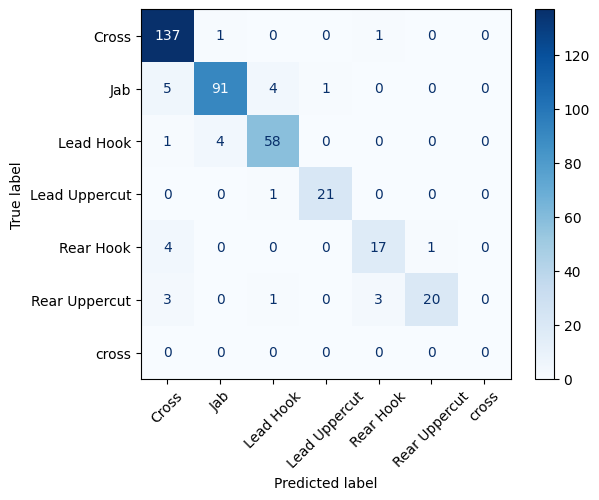

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=range(len(le.classes_)))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()